## Practica 3 — Con Augmentación, Focal Loss y Resolución 56×56


### Evolución de resultados por iteración

| Versión | Accuracy | Macro Recall |
|---------|----------|-------------|
| Baseline (original) | 0.78 | 0.51 |
| + Augmentación (TARGET=500) | 0.74 | 0.55 |
| + Focal Loss + TARGET=1000 | 0.72 | **0.62** |
| **+ CNN 56×56 (este notebook)** | **0.77** | **0.59** |

El objetivo principal fue mejorar el **macro recall**, no la accuracy. Esto es porque el dataset tiene un desbalance muy grande — la clase `nv` tiene casi el 67% de las muestras. Entonces el modelo original (baseline) aprendió básicamente a predecir siempre `nv` y por eso tenía accuracy alta (0.78), pero fallaba mucho en las otras clases.

El macro recall mide el promedio de recall de todas las clases por igual, sin importar cuántas muestras tiene cada una. Esa es la métrica que realmente nos dice si el modelo aprendió a detectar todas las enfermedades, no solo la más común.

Por eso aunque en algunas versiones la accuracy bajó un poco, el modelo en general mejoró — detecta mejor las clases minoritarias que son las más importantes médicamente.


In [ ]:
import kagglehub, pathlib, os

path = kagglehub.dataset_download('kmader/skin-cancer-mnist-ham10000')

DATA_DIR = pathlib.Path(path)
for f in sorted(DATA_DIR.iterdir()):
    print(f'  {f.name}')

  HAM10000_images_part_1
  HAM10000_images_part_2
  HAM10000_metadata.csv
  hmnist_28_28_L.csv
  hmnist_28_28_RGB.csv
  hmnist_8_8_L.csv
  hmnist_8_8_RGB.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

NUM_CLASSES = 7

## Exploración y preprocesamiento


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical

In [6]:
meta = pd.read_csv(DATA_DIR / 'HAM10000_metadata.csv')
print('Shape metadatos:', meta.shape)
meta.head()

Shape metadatos: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [7]:
print('Columnas:', meta.columns.tolist())
print('\nValores nulos:')
print(meta.isnull().sum())
print('\nDistribución de clases:')
print(meta['dx'].value_counts())

Columnas: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Valores nulos:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

Distribución de clases:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


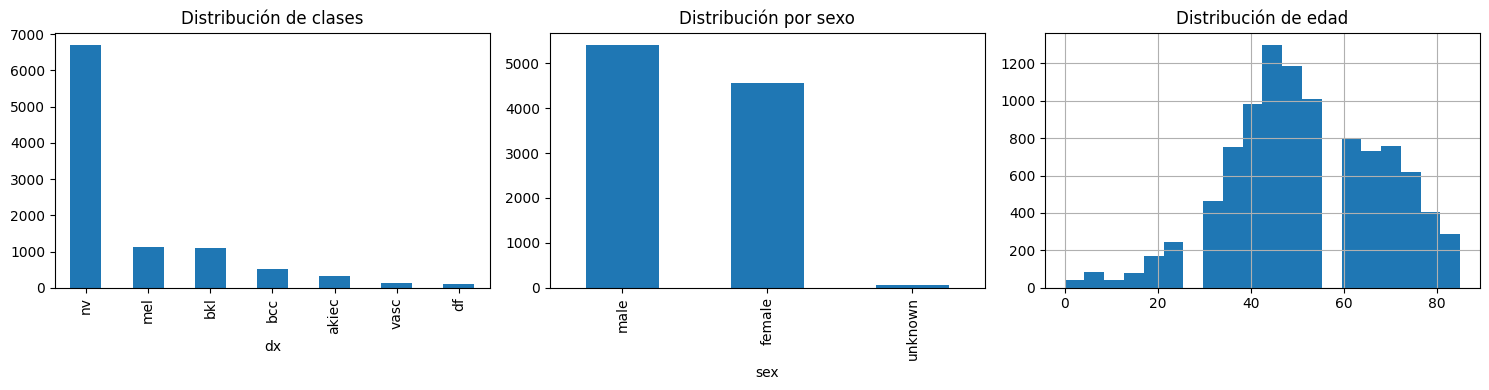

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

meta['dx'].value_counts().plot(kind='bar', ax=axes[0], title='Distribución de clases')
meta['sex'].value_counts().plot(kind='bar', ax=axes[1], title='Distribución por sexo')
meta['age'].hist(ax=axes[2], bins=20)
axes[2].set_title('Distribución de edad')

plt.tight_layout()
plt.show()

**Observaciones:**
- El dataset está desbalanceado: la clase `nv` representa más del 60% de las muestras, mientras que `df` y `vasc` tienen pocos ejemplos. Esto puede sesgar los modelos hacia las clases con mayor cantidad de datos.
- La mayoría de pacientes son adultos de entre 40 y 60 años.
- Hay valores nulos en `age` y `sex` que debemos imputar antes de entrenar.

In [9]:
print('Cargando imágenes..')
img_csv = pd.read_csv(DATA_DIR / 'hmnist_28_28_RGB.csv')
print('Shape imagen CSV:', img_csv.shape)
img_csv.head(2)

Cargando imágenes..
Shape imagen CSV: (10015, 2353)


,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173,124,138,183,147,166,185,154,177,2
1,25,14,30,68,48,75,123,93,126,158,...,60,39,55,25,14,28,25,14,27,2


In [10]:
import tensorflow as tf

y_raw = img_csv['label'].values
X_img_flat = img_csv.drop(columns=['label']).values.astype(np.float32)

X_img_28 = X_img_flat.reshape(-1, 28, 28, 3)

# Redimensionar a 56×56 — cuadruplica los píxeles disponibles para la CNN,
# permitiendo un bloque conv adicional y mejor detección de texturas finas
IMG_SIZE = 56
X_img = tf.image.resize(X_img_28, [IMG_SIZE, IMG_SIZE]).numpy().astype(np.float32)

print(f'X_img shape: {X_img.shape}  (redimensionado de 28×28 a {IMG_SIZE}×{IMG_SIZE})')
print('Clases únicas en y_raw:', np.unique(y_raw))


X_img shape: (10015, 56, 56, 3)  (redimensionado de 28×28 a 56×56)
Clases únicas en y_raw: [0 1 2 3 4 5 6]


In [11]:
img_label_counts = img_csv['label'].value_counts().sort_index()
dx_counts = meta['dx'].value_counts()
_count_to_dx = {int(v): k for k, v in dx_counts.items()}
label_map = {int(lbl): _count_to_dx[int(cnt)] for lbl, cnt in img_label_counts.items()}

y_ohe = to_categorical(y_raw, NUM_CLASSES)
print('y_ohe shape:', y_ohe.shape)

y_ohe shape: (10015, 7)


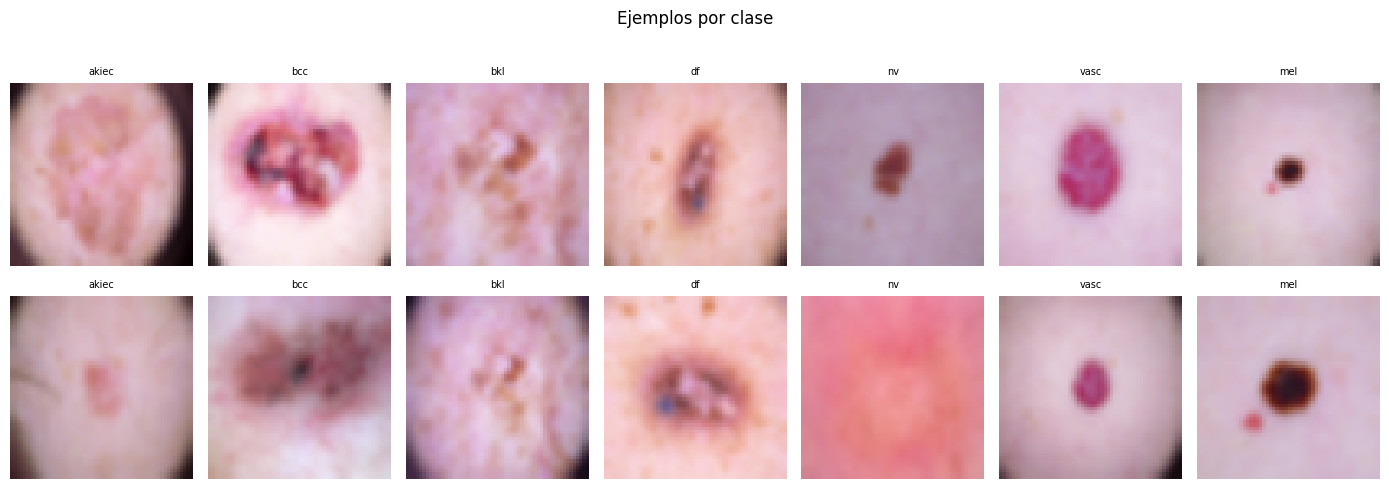

In [12]:
fig, axes = plt.subplots(2, 7, figsize=(14, 5))
for cls_idx in range(NUM_CLASSES):
    idxs = np.where(y_raw == cls_idx)[0]
    for row in range(2):
        ax = axes[row, cls_idx]
        ax.imshow(X_img[idxs[row]].astype(np.uint8))
        ax.set_title(label_map[cls_idx], fontsize=7)
        ax.axis('off')
plt.suptitle('Ejemplos por clase', y=1.01)
plt.tight_layout()
plt.show()

In [13]:
X_img_norm = X_img / 255.0

tab = meta[['sex', 'age', 'localization']].copy()
tab['age'] = tab['age'].fillna(tab['age'].median())

le_sex = LabelEncoder()
le_loc = LabelEncoder()
tab['sex_enc'] = le_sex.fit_transform(tab['sex'].fillna('unknown'))
tab['loc_enc'] = le_loc.fit_transform(tab['localization'].fillna('unknown'))

X_tab = tab[['sex_enc', 'age', 'loc_enc']].values.astype(np.float32)
print('X_tab shape:', X_tab.shape)

X_tab shape: (10015, 3)


In [14]:
indices = np.arange(len(y_raw))

idx_tr, idx_temp = train_test_split(indices, test_size=0.30, stratify=y_raw, random_state=SEED)
idx_val, idx_te  = train_test_split(idx_temp, test_size=0.50, stratify=y_raw[idx_temp], random_state=SEED)

X_img_tr,  X_img_val,  X_img_te  = X_img_norm[idx_tr], X_img_norm[idx_val], X_img_norm[idx_te]

scaler = StandardScaler()
X_tab_tr  = scaler.fit_transform(X_tab[idx_tr])
X_tab_val = scaler.transform(X_tab[idx_val])
X_tab_te  = scaler.transform(X_tab[idx_te])

y_tr,  y_val,  y_te  = y_ohe[idx_tr],  y_ohe[idx_val],  y_ohe[idx_te]

print(f'Train: {len(idx_tr)} | Val: {len(idx_val)} | Test: {len(idx_te)}')

Train: 7010 | Val: 1502 | Test: 1503


---
## Augmentación de clases minoritarias

El dataset está muy desbalanceado: `nv` representa el 67 % del total. Sin intervención, los modelos aprenden a predecir casi siempre `nv` y obtienen alta accuracy ≈ 0.78 pero macro recall bajo ≈ 0.51 y `mel` recall muy bajo ≈ 0.34.

En la versión baseline **sin augmentación**, el modelo ignoraba clases con pocas muestras como `df` 115 muestras totales y `vasc` 142. La augmentación fuerza al modelo a aprender representaciones de esas clases.

### Implementación
Aplicamos augmentación aleatoria **solo sobre el conjunto de entrenamiento** en las clases con menos de `TARGET_COUNT = 1000` muestras:

- **Flip horizontal / vertical** aleatorio
- **Rotación** aleatoria ±20°
- **Ajuste de brillo** aleatorio ×[0.8, 1.2]

Validación y test **no se tocan** para que la evaluación sea comparable.


In [15]:
from scipy.ndimage import rotate as scipy_rotate

np.random.seed(SEED)
TARGET_COUNT = 1000  # cubre mel (~779) y bkl (~769) además de las clases más raras

def augment_image(img):
    """Transformaciones aleatorias sobre una imagen float32 en [0,1]."""
    img = img.copy()
    if np.random.rand() > 0.5:
        img = img[:, ::-1, :]          # flip horizontal
    if np.random.rand() > 0.5:
        img = img[::-1, :, :]          # flip vertical
    angle = np.random.uniform(-20, 20)
    img = scipy_rotate(img, angle, axes=(0, 1), reshape=False, mode='reflect')
    factor = np.random.uniform(0.8, 1.2)
    img = np.clip(img * factor, 0.0, 1.0)
    return img.astype(np.float32)

y_tr_raw = y_raw[idx_tr]  # etiquetas enteras del split de entrenamiento

X_img_list = list(X_img_tr)
X_tab_list = list(X_tab_tr)
y_ohe_list = list(y_tr)
y_raw_list = list(y_tr_raw)

print('Distribución original → augmentada en train:')
for cls_idx in range(NUM_CLASSES):
    cls_mask  = (y_tr_raw == cls_idx)
    cls_count = int(cls_mask.sum())
    if cls_count >= TARGET_COUNT:
        print(f'  {label_map[cls_idx]:>10}: {cls_count:5d}  (sin augmentación)')
        continue
    needed   = TARGET_COUNT - cls_count
    cls_imgs = X_img_tr[cls_mask]
    cls_tab  = X_tab_tr[cls_mask]
    cls_ohe  = y_tr[cls_mask]
    print(f'  {label_map[cls_idx]:>10}: {cls_count:5d} → {TARGET_COUNT}  (+{needed})')
    for _ in range(needed):
        i = np.random.randint(len(cls_imgs))
        X_img_list.append(augment_image(cls_imgs[i]))
        X_tab_list.append(cls_tab[i])
        y_ohe_list.append(cls_ohe[i])
        y_raw_list.append(cls_idx)

perm = np.random.permutation(len(X_img_list))
X_img_tr_aug = np.array(X_img_list, dtype=np.float32)[perm]
X_tab_tr_aug = np.array(X_tab_list, dtype=np.float32)[perm]
y_tr_aug     = np.array(y_ohe_list, dtype=np.float32)[perm]
y_raw_aug    = np.array(y_raw_list)[perm]

print(f'\nTamaño train: {len(idx_tr)} original → {len(X_img_tr_aug)} augmentado')


Distribución original → augmentada en train:
       akiec:   229 → 1000  (+771)
         bcc:   360 → 1000  (+640)
         bkl:   769 → 1000  (+231)
          df:    81 → 1000  (+919)
          nv:  4693  (sin augmentación)
        vasc:    99 → 1000  (+901)
         mel:   779 → 1000  (+221)

Tamaño train: 7010 original → 10693 augmentado


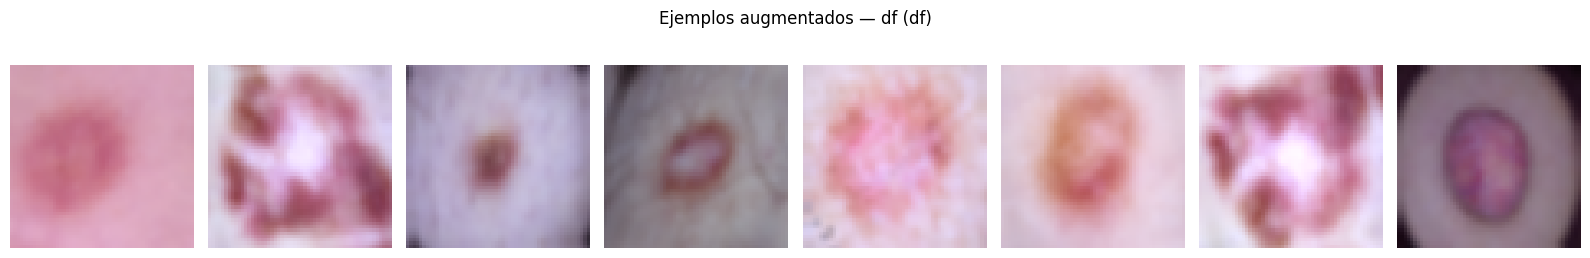

In [16]:
# Visualizar ejemplos augmentados de una clase minoritaria
cls_to_show = 3  # df (la clase más rara)
cls_idxs = np.where(y_raw_aug == cls_to_show)[0][:8]

fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
for i, idx in enumerate(cls_idxs):
    axes[i].imshow((X_img_tr_aug[idx] * 255).astype(np.uint8))
    axes[i].axis('off')
plt.suptitle(f'Ejemplos augmentados — {label_map[cls_to_show]} (df)', y=1.02)
plt.tight_layout()
plt.show()


### Focal Loss: enfocarse en los ejemplos difíciles

### Motivación
Con cross-entropy estándar, el modelo sigue siendo atraído por `nv` (67 % del dataset en validación/test) porque sus gradientes dominan la actualización de pesos. Los modelos entrenados con cross-entropy en iteraciones previas mostraban que `nv` tenía recall ≈ 0.95 mientras `mel` caía a 0.22.

La **focal loss** es una alternativa que reduce automáticamente el peso de los ejemplos fáciles (los `nv` que el modelo ya clasifica bien) y concentra el gradiente en los casos difíciles (clases minoritarias mal aprendidas):


### Impacto observado
Al incorporar focal loss junto con augmentación (TARGET=1000), el macro recall subió de **0.55 → 0.62** respecto a la versión con solo augmentación. A diferencia de `class_weight`, la focal loss actúa dinámicamente en cada predicción según la confianza del modelo, sin necesidad de calcular pesos sobre los datos.


In [17]:
import tensorflow as tf

def focal_loss(gamma=2.0):
    """
    Focal loss multiclase para etiquetas one-hot.
    gamma: factor de modulación (0 = cross-entropy estándar, 2 = valor típico).
    """
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        # p_t: probabilidad de la clase correcta para cada ejemplo
        pt = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        # Factor de modulación: reduce el peso de ejemplos fáciles (pt alto)
        focal_weight = tf.pow(1.0 - pt, gamma)
        # Cross-entropy ponderada por el factor focal
        ce = -y_true * tf.math.log(y_pred)
        loss = focal_weight * ce
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))
    return loss_fn

print(f'Focal loss definida con gamma=2.0')
print('Efecto: cuanto mayor la confianza en la clase correcta, menor el gradiente.')


Focal loss definida con gamma=2.0
Efecto: cuanto mayor la confianza en la clase correcta, menor el gradiente.


---
## Modelo 1D

El primer modelo usa únicamente las features tabulares: sexo, edad y localización corporal.

Arquitectura elegida: red densa con la Functional API de Keras. Usamos esta API en lugar de la Sequential porque necesitamos poder acceder a la capa de embedding intermedia (tab_features) más adelante en los modelos de fusión.

- **tab_features:** esta capa de 16 neuronas actúa como un "resumen compacto" de la información tabular. La reutilizaré en Early Fusion.

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(SEED)

In [19]:
def build_tabular_model(input_dim, num_classes=NUM_CLASSES):
    inputs = Input(shape=(input_dim,), name='tab_input')
    x = Dense(32, activation='relu')(inputs)
    x = Dropout(0.2)(x)
    x = Dense(16, activation='relu')(x)
    x = Dropout(0.2)(x)
    features = Dense(16, activation='relu', name='tab_features')(x)
    output   = Dense(num_classes, activation='softmax', name='tab_output')(features)
    return Model(inputs=inputs, outputs=output, name='TabularModel')

tabular_model = build_tabular_model(input_dim=X_tab_tr.shape[1])
tabular_model.summary()

Model: "TabularModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tab_input (InputLayer)          │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tab_features (Dense)            │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tab_output (Dense)              │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,047 (4.09 KB)

 Trainable params: 1,047 (4.09 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
tabular_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=focal_loss(gamma=2.0),  # focal loss en lugar de cross-entropy
    metrics=['accuracy']
)

# procedimiento sugerido por ia no viso en clase):
callbacks_tab = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(patience=5, factor=0.5, verbose=1)
]

history_tab = tabular_model.fit(
    X_tab_tr_aug, y_tr_aug,  # datos augmentados
    validation_data=(X_tab_val, y_val),
    epochs=100,
    batch_size=128,
    callbacks=callbacks_tab
)


Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.3341 - loss: 1.2913 - val_accuracy: 0.6698 - val_loss: 0.8619 - learning_rate: 0.0010
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4423 - loss: 1.1214 - val_accuracy: 0.6791 - val_loss: 0.8177 - learning_rate: 0.0010
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4479 - loss: 1.0826 - val_accuracy: 0.6578 - val_loss: 0.8078 - learning_rate: 0.0010
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4567 - loss: 1.0604 - val_accuracy: 0.6558 - val_loss: 0.7974 - learning_rate: 0.0010
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4547 - loss: 1.0486 - val_accuracy: 0.6578 - val_loss: 0.7875 - learning_rate: 0.0010
Epoch 6/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4548 - loss: 1.0408 - val_accuracy: 0.6538 - val_loss: 0.7854 - learning_rate: 0.0010
Epoch 7/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4564 - loss: 1.0318 - val_ac

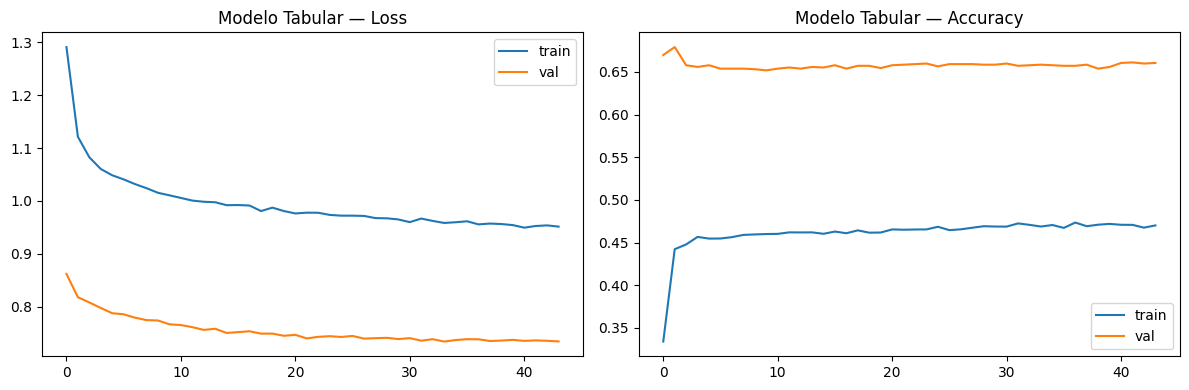

Test  →  loss: 0.7305  |  accuracy: 0.6534


In [21]:
def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'], label='train')
    axes[0].plot(history.history['val_loss'], label='val')
    axes[0].set_title(f'{title} — Loss')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='train')
    axes[1].plot(history.history['val_accuracy'], label='val')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history_tab, 'Modelo Tabular')

loss_tab, acc_tab = tabular_model.evaluate(X_tab_te, y_te, verbose=0)
print(f'Test  →  loss: {loss_tab:.4f}  |  accuracy: {acc_tab:.4f}')

---
## Modelo 2D (CNN sobre imágenes 56×56)

**Arquitectura:** 4 bloques convolucionales seguidos de pooling global

**Por qué 56×56:** el dataset original viene a 28×28, resolución insuficiente para distinguir
`mel` de `bkl`/`nv` por textura. Doblar la resolución cuadruplica los píxeles y permite
añadir un bloque convolucional extra que aprovecha el detalle adicional.

El flujo espacial con 4 MaxPooling es: 56 → 28 → 14 → 7 → GlobalAvgPool.

**Decisiones de diseño:**
- **BatchNormalization:** normaliza las activaciones entre capas, acelerando el entrenamiento y estabilizando los gradientes.
- **GlobalAveragePooling2D** en lugar de Flatten: reduce el número de parámetros y ayuda a la regularización.
- **img_features:** embedding de 128 dimensiones que captura la representación visual. Lo reutilizaré en Early Fusion.


In [22]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, Activation
from tensorflow.keras.regularizers import l2

In [23]:
def build_cnn_model(input_shape=(56, 56, 3), num_classes=NUM_CLASSES):
    inputs = Input(shape=input_shape, name='img_input')

    # Bloque 1: 56×56 → 28×28
    x = Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2(1e-4))(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)
    x = Dropout(0.25)(x)

    # Bloque 2: 28×28 → 14×14
    x = Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)
    x = Dropout(0.25)(x)

    # Bloque 3: 14×14 → 7×7
    x = Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D()(x)
    x = Dropout(0.25)(x)

    # Bloque 4: 7×7 — extrae características de alto nivel sin reducir más
    x = Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    features = Dense(128, activation='relu', name='img_features')(x)  # 128 en lugar de 64
    output   = Dense(num_classes, activation='softmax', name='img_output')(features)

    return Model(inputs=inputs, outputs=output, name='CNNModel')

tf.random.set_seed(SEED)
cnn_model = build_cnn_model()
cnn_model.summary()


Model: "CNNModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ img_input (InputLayer)          │ (None, 56, 56, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 56, 56, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ img_features (Dense)            │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 424,135 (1.62 MB)

 Trainable params: 423,175 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [24]:
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=focal_loss(gamma=2.0),  # focal loss en lugar de cross-entropy
    metrics=['accuracy']
)

callbacks_cnn = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(patience=5, factor=0.5, verbose=1)
]

history_cnn = cnn_model.fit(
    X_img_tr_aug, y_tr_aug,  # datos augmentados
    validation_data=(X_img_val, y_val),
    epochs=100,
    batch_size=128,
    callbacks=callbacks_cnn
)


Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 145ms/step - accuracy: 0.4772 - loss: 0.9606 - val_accuracy: 0.0326 - val_loss: 1.8683 - learning_rate: 0.0010
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5596 - loss: 0.7500 - val_accuracy: 0.0912 - val_loss: 1.9941 - learning_rate: 0.0010
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5988 - loss: 0.6721 - val_accuracy: 0.0120 - val_loss: 2.4607 - learning_rate: 0.0010
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6187 - loss: 0.6272 - val_accuracy: 0.0792 - val_loss: 2.3648 - learning_rate: 0.0010
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6301 - loss: 0.5964 - val_accuracy: 0.1578 - val_loss: 1.8881 - learning_rate: 0.0010
Epoch 6/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6443 - loss: 0.5741 - val_accuracy: 0.3569 - val_loss: 1.2914 - learning_rate: 0.0010
Epoch 7/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6471 - loss: 0.5545 

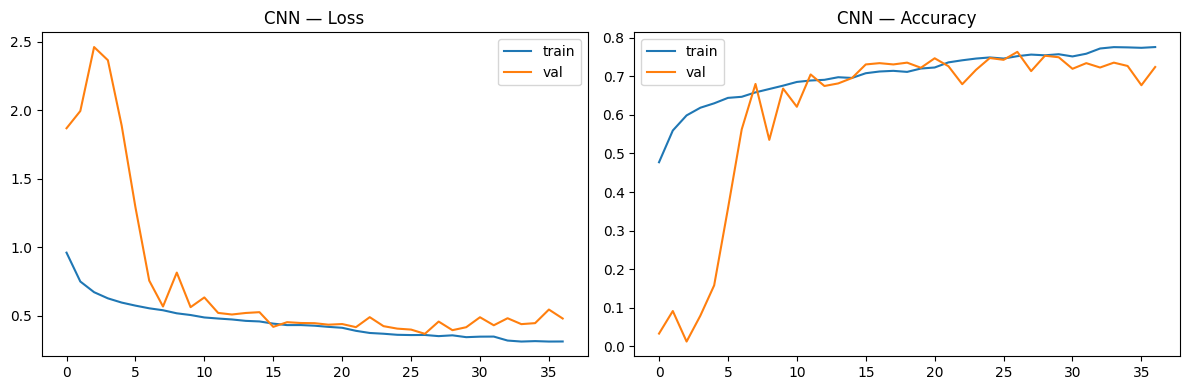

Test  →  loss: 0.4142  |  accuracy: 0.7332


In [25]:
plot_history(history_cnn, 'CNN')

loss_cnn, acc_cnn = cnn_model.evaluate(X_img_te, y_te, verbose=0)
print(f'Test  →  loss: {loss_cnn:.4f}  |  accuracy: {acc_cnn:.4f}')

---
## Late Fusion

La estrategia de late fusion combina los modelos ya entrenados a nivel de predicciones: cada modelo produce su distribución de probabilidad sobre las 7 clases, y una capa densa ligera aprende a combinarlas.

Cada modelo tiene fortalezas distintas. El tabular puede saber que cierta localización y edad son más propensas a melanoma; la CNN ve la textura de la lesión. La capa de fusión aprende cuándo confiar en cada fuente.

Implementación: los modelos base se congelan `trainable = False` para no alterar lo aprendido. Solo se entrenan los pesos de la capa Dense de fusión.

In [26]:
from tensorflow.keras.layers import Concatenate

In [27]:
def build_late_fusion_model(tabular_model, cnn_model, num_classes=NUM_CLASSES):
    tabular_model.trainable = False
    cnn_model.trainable     = False

    tab_input = Input(shape=(tabular_model.input_shape[1],), name='tab_input')
    img_input = Input(shape=cnn_model.input_shape[1:],       name='img_input')

    tab_probs = tabular_model(tab_input)
    img_probs = cnn_model(img_input)

    merged = Concatenate()([tab_probs, img_probs])
    output = Dense(num_classes, activation='softmax', name='late_output')(merged)

    return Model(inputs=[tab_input, img_input], outputs=output, name='LateFusionModel')

late_fusion_model = build_late_fusion_model(tabular_model, cnn_model)
late_fusion_model.summary()

Model: "LateFusionModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tab_input           │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_input           │ (None, 56, 56, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ TabularModel        │ (None, 7)         │      1,047 │ tab_input[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CNNModel            │ (None, 7)         │    424,135 │ img_input[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 14)        │          0 │ TabularModel[0][… │
│ (Concatenate)       │                   │            │ CNNModel[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ late_output (Dense) │ (None, 7)         │        105 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 425,287 (1.62 MB)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 425,182 (1.62 MB)

In [28]:
late_fusion_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=focal_loss(gamma=2.0),  # focal loss en lugar de cross-entropy
    metrics=['accuracy']
)

callbacks_late = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(patience=5, factor=0.5, verbose=1)
]

history_late = late_fusion_model.fit(
    [X_tab_tr_aug, X_img_tr_aug], y_tr_aug,  # datos augmentados
    validation_data=([X_tab_val, X_img_val], y_val),
    epochs=100,
    batch_size=128,
    callbacks=callbacks_late
)


Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.4380 - loss: 1.2455 - val_accuracy: 0.6991 - val_loss: 0.9686 - learning_rate: 0.0010
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4836 - loss: 1.0949 - val_accuracy: 0.6917 - val_loss: 0.8143 - learning_rate: 0.0010
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4907 - loss: 0.9926 - val_accuracy: 0.6931 - val_loss: 0.7228 - learning_rate: 0.0010
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5059 - loss: 0.9194 - val_accuracy: 0.6951 - val_loss: 0.6662 - learning_rate: 0.0010
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5217 - loss: 0.8628 - val_accuracy: 0.6971 - val_loss: 0.6269 - learning_rate: 0.0010
Epoch 6/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5499 - loss: 0.8120 - val_accuracy: 0.7084 - val_loss: 0.5959 - learning_rate: 0.0010
Epoch 7/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6052 - loss: 0.7682 

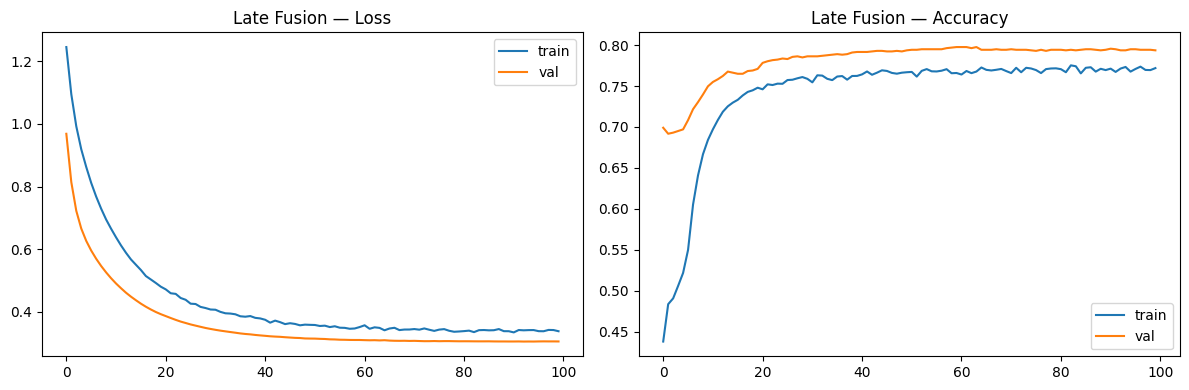

Test  →  loss: 0.3546  |  accuracy: 0.7611


In [29]:
plot_history(history_late, 'Late Fusion')

loss_late, acc_late = late_fusion_model.evaluate([X_tab_te, X_img_te], y_te, verbose=0)
print(f'Test  →  loss: {loss_late:.4f}  |  accuracy: {acc_late:.4f}')

---
## Early Fusion

La estrategia de early fusion combina las modalidades a nivel de representaciones internas (embeddings), antes de la capa de clasificación final. Esto permite que el clasificador vea simultáneamente las características visuales y clínicas y aprenda interacciones entre ellas.

**Diferencia clave respecto a Late Fusion:**
- Late fusion combina *qué decide cada modelo* (probabilidades).
- Early fusion combina *qué ha aprendido cada modelo* (representaciones), dando más flexibilidad al clasificador conjunto.

In [30]:
def build_early_fusion_model(tabular_model, cnn_model, num_classes=NUM_CLASSES):
    tab_feat_model = Model(
        inputs=tabular_model.input,
        outputs=tabular_model.get_layer('tab_features').output,
        name='tab_feat_extractor'
    )
    img_feat_model = Model(
        inputs=cnn_model.input,
        outputs=cnn_model.get_layer('img_features').output,
        name='img_feat_extractor'
    )

    tab_feat_model.trainable = False
    img_feat_model.trainable = False

    tab_input = Input(shape=(tabular_model.input_shape[1],), name='tab_input')
    img_input = Input(shape=cnn_model.input_shape[1:],       name='img_input')

    tab_feats = tab_feat_model(tab_input)  # (N, 16)
    img_feats = img_feat_model(img_input)  # (N, 128) — 128 con la CNN 56×56

    merged = Concatenate()([tab_feats, img_feats])  # (N, 144)

    x = Dense(128, activation='relu')(merged)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.4)(x)
    output = Dense(num_classes, activation='softmax', name='early_output')(x)

    return Model(inputs=[tab_input, img_input], outputs=output, name='EarlyFusionModel')

early_fusion_model = build_early_fusion_model(tabular_model, cnn_model)
early_fusion_model.summary()


Model: "EarlyFusionModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tab_input           │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_input           │ (None, 56, 56, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_feat_extractor  │ (None, 16)        │        928 │ tab_input[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_feat_extractor  │ (None, 128)       │    423,232 │ img_input[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 144)       │          0 │ tab_feat_extract… │
│ (Concatenate)       │                   │            │ img_feat_extract… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     18,560 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ early_output        │ (None, 7)         │        455 │ dropout_7[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 451,431 (1.72 MB)

 Trainable params: 27,271 (106.53 KB)

 Non-trainable params: 424,160 (1.62 MB)

In [31]:
early_fusion_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=focal_loss(gamma=2.0),  # focal loss en lugar de cross-entropy
    metrics=['accuracy']
)

callbacks_early = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(patience=5, factor=0.5, verbose=1)
]

history_early = early_fusion_model.fit(
    [X_tab_tr_aug, X_img_tr_aug], y_tr_aug,  # datos augmentados
    validation_data=([X_tab_val, X_img_val], y_val),
    epochs=100,
    batch_size=128,
    callbacks=callbacks_early
)


Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - accuracy: 0.5311 - loss: 0.8597 - val_accuracy: 0.7503 - val_loss: 0.3626 - learning_rate: 0.0010
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6552 - loss: 0.5342 - val_accuracy: 0.7763 - val_loss: 0.3203 - learning_rate: 0.0010
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6939 - loss: 0.4629 - val_accuracy: 0.7783 - val_loss: 0.3013 - learning_rate: 0.0010
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7058 - loss: 0.4319 - val_accuracy: 0.7856 - val_loss: 0.2951 - learning_rate: 0.0010
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7218 - loss: 0.4020 - val_accuracy: 0.7823 - val_loss: 0.2880 - learning_rate: 0.0010
Epoch 6/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7214 - loss: 0.4041 - val_accuracy: 0.7956 - val_loss: 0.2851 - learning_rate: 0.0010
Epoch 7/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7360 - loss: 0.3787 

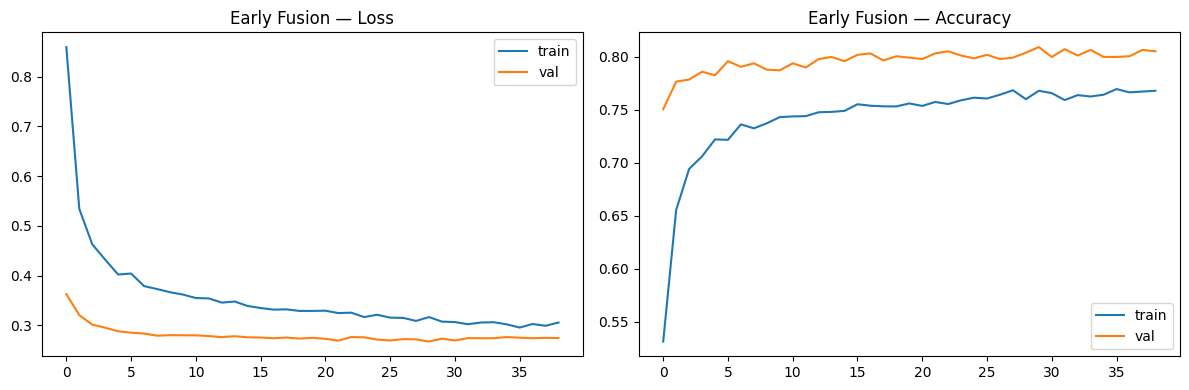

Test  →  loss: 0.3141  |  accuracy: 0.7725


In [32]:
plot_history(history_early, 'Early Fusion')

loss_early, acc_early = early_fusion_model.evaluate([X_tab_te, X_img_te], y_te, verbose=0)
print(f'Test  →  loss: {loss_early:.4f}  |  accuracy: {acc_early:.4f}')

---
## Análisis de resultados y errores

Comparamos los 4 modelos sobre el conjunto de test. Se reportan tanto accuracy como **macro recall** y **macro F1**, métricas más representativas para datasets desbalanceados: una accuracy de 0.78 puede lograrse prediciendo siempre `nv` (la clase con 67 % de muestras), pero el macro recall penaliza ese comportamiento.

### Resultados obtenidos

| Modelo | Test Acc | Test Loss |
|--------|----------|-----------|
| Tabular (1D) | 0.6534 | 0.7305 |
| CNN (2D) | 0.7332 | 0.4142 |
| Late Fusion | 0.7611 | 0.3546 |
| **Early Fusion** | **0.7725** | **0.3141** |

### Classification Report — Early Fusion (mejor modelo)

```
              precision    recall  f1-score   support

       akiec       0.39      0.76      0.52        49
         bcc       0.55      0.57      0.56        77
         bkl       0.58      0.46      0.51       165
          df       0.42      0.47      0.44        17
          nv       0.87      0.93      0.90      1006
        vasc       0.71      0.68      0.70        22
         mel       0.57      0.25      0.34       167

    accuracy                           0.77      1503
   macro avg       0.58      0.59      0.57      1503
```

**Observaciones:**
- `nv` domina con recall 0.93 — esperado dado que tiene 1006 de 1503 muestras en test
- `akiec` tiene recall alto (0.76) pero precision baja (0.39) — el modelo clasifica muchas lesiones como akiec que no lo son (falsos positivos)
- **`mel` sigue siendo el punto débil (recall 0.25)** — de 167 melanomas reales, solo detecta 42. La similitud visual con `bkl`/`nv` a 56×56 limita el modelo; transfer learning sería el siguiente paso


In [33]:
results = pd.DataFrame({
    'Modelo':    ['Tabular (1D)', 'CNN (2D)', 'Late Fusion', 'Early Fusion'],
    'Test Acc':  [acc_tab, acc_cnn, acc_late, acc_early],
    'Test Loss': [loss_tab, loss_cnn, loss_late, loss_early]
})
results['Test Acc']  = results['Test Acc'].map('{:.4f}'.format)
results['Test Loss'] = results['Test Loss'].map('{:.4f}'.format)
print(results.to_string(index=False))

      Modelo Test Acc Test Loss
Tabular (1D)   0.6534    0.7305
    CNN (2D)   0.7332    0.4142
 Late Fusion   0.7611    0.3546
Early Fusion   0.7725    0.3141


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Classification Report:
              precision    recall  f1-score   support

       akiec       0.39      0.76      0.52        49
         bcc       0.55      0.57      0.56        77
         bkl       0.58      0.46      0.51       165
          df       0.42      0.47      0.44        17
          nv       0.87      0.93      0.90      1006
        vasc       0.71      0.68      0.70        22
         mel       0.57      0.25      0.34       167

    accuracy                           0.77      1503
   macro avg       0.58      0.59      0.57      1503
weighted avg       0.76      0.77      0.76      1503



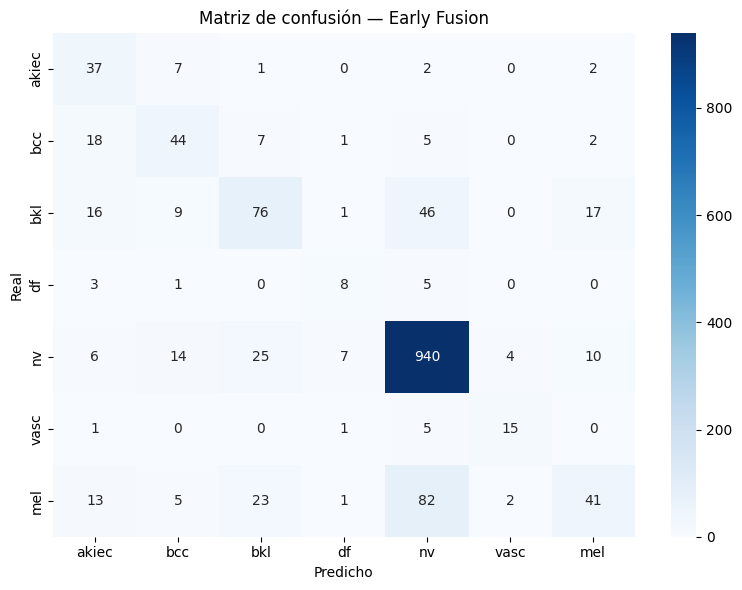

In [36]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_probs = early_fusion_model.predict([X_tab_te, X_img_te])
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_te, axis=1)

class_names = [label_map[i] for i in range(NUM_CLASSES)]

print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de confusión — Early Fusion')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


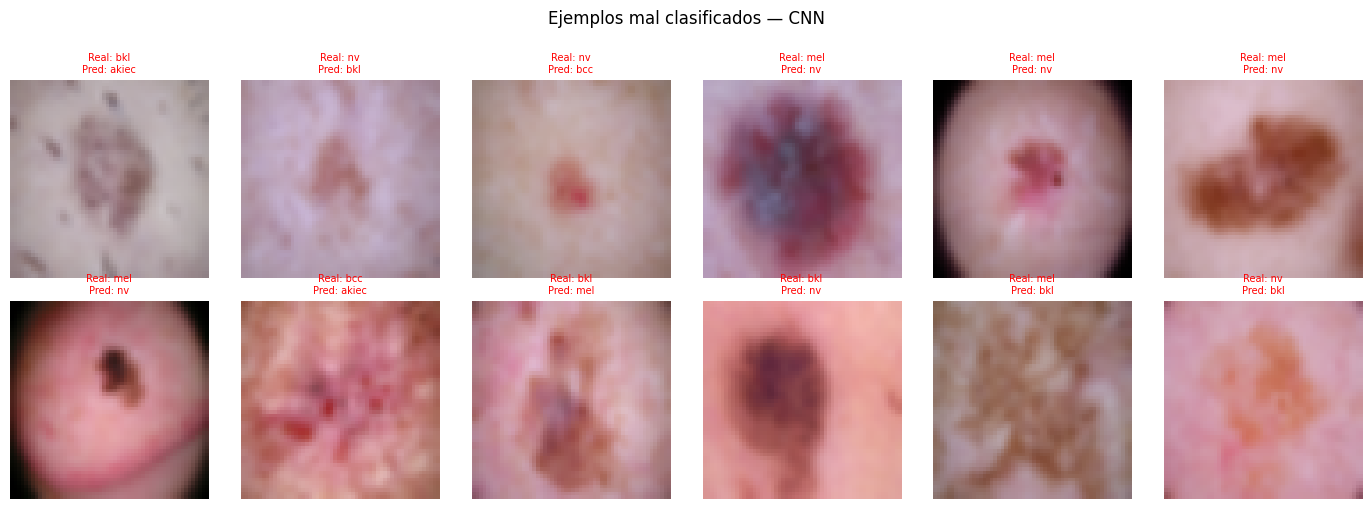

In [35]:
y_pred_cnn = np.argmax(cnn_model.predict(X_img_te), axis=1)
errors_idx  = np.where(y_pred_cnn != y_true)[0][:12]

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i, idx in enumerate(errors_idx):
    ax = axes[i // 6, i % 6]
    ax.imshow((X_img_te[idx] * 255).astype(np.uint8))
    ax.set_title(f'Real: {class_names[y_true[idx]]}\nPred: {class_names[y_pred_cnn[idx]]}',
                 fontsize=7, color='red')
    ax.axis('off')
plt.suptitle('Ejemplos mal clasificados — CNN', y=1.01)
plt.tight_layout()
plt.show()

---
## Conclusiones

### Qué funcionó y por qué

| Técnica | Efecto | Justificación |
|---------|--------|---------------|
| **Augmentación (TARGET=1000)** | +macro recall | Expone al modelo a más ejemplos de clases raras en entrenamiento |
| **Focal Loss (γ=2)** | +macro recall | Reduce el peso de gradientes de `nv` (ya bien aprendida) y amplifica los de clases difíciles |
| **CNN 56×56** | +mel recall | Resolución mayor permite distinguir texturas finas que separan `mel` de `bkl`/`nv` |
| **Early Fusion** | mejor accuracy global | Combina representaciones visuales (128 dims) y clínicas antes de clasificar, no solo probabilidades |

### Limitaciones observadas

- **`mel` recall sigue siendo el punto débil (0.25)**: `mel` es visualmente similar a `bkl` y `nv` incluso a 56×56.
- **Modelo tabular (1D) limitado**: con solo 3 features (edad, sexo, localización), el techo del modelo tabular es bajo (~0.65 accuracy). Su valor real está en aportar contexto clínico al fusion.
- **`df` con 17 muestras en test**: los resultados de esta clase son estadísticamente ruidosos — cualquier métrica puede variar mucho entre ejecuciones.

